# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [33]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [34]:
print(df.shape)
df.info()

(541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [35]:
print("Missing values :\n",df.isnull().sum())
print("Duplicate :", df.duplicated().sum())


Missing values :
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicate : 5268


## A.3. Invalid values

In [36]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
rules = {
    "InvoiceNo ": df['InvoiceNo'].isna() | (df['InvoiceNo'].astype(str).str.strip() == ''),
    "StockCode ": df['StockCode'].isna() | (df['StockCode'].astype(str).str.strip() == ''),
    "Description ": df['Description'].isna() | (df['Description'].astype(str).str.strip() == ''),
    "Quantity ": df['Quantity'] <= 0, 
    "UnitPrice ": df['UnitPrice'] <= 0,
    "CustomerID ": df['CustomerID'].isna(),  
    "InvoiceDate ": df['InvoiceDate'].isna(),
    "Country ": df['Country'].isna() | (df['Country'].astype(str).str.strip() == '')
}

for label, condition in rules.items():
    print(f"Invalid {label}: {condition.sum()}")


Invalid InvoiceNo : 0
Invalid StockCode : 0
Invalid Description : 1454
Invalid Quantity : 10624
Invalid UnitPrice : 2517
Invalid CustomerID : 135080
Invalid InvoiceDate : 0
Invalid Country : 0


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [37]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
print(df_clean[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'Sales']].head())


  InvoiceNo StockCode  Quantity  UnitPrice  Sales
0    536365    85123A         6       2.55  15.30
1    536365     71053         6       3.39  20.34
2    536365    84406B         8       2.75  22.00
3    536365    84029G         6       3.39  20.34
4    536365    84029E         6       3.39  20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [41]:
def get_dispersion_stats(df, columns):
    stats = {}
    for col in columns:
        s = df[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        mean = s.mean()
        std = s.std()
        
        stats[col] = {
            'Min': s.min(),
            'Max': s.max(),
            'Range': s.max() - s.min(),
            'Variance': s.var(),
            'Std Dev': std,
            'Q1 (25%)': q1,
            'Q3 (75%)': q3,
            'IQR': q3 - q1,
            'CV (%)': (std / mean) * 100 if mean != 0 else np.nan
        }
    return pd.DataFrame(stats)

# Gọi hàm cho các cột số
dispersion_df = get_dispersion_stats(df_clean, ['Quantity', 'UnitPrice', 'Sales'])
print(dispersion_df.round(2))

          Quantity  UnitPrice      Sales
Min           1.00       0.00       0.00
Max       80995.00   13541.33  168469.60
Range     80994.00   13541.33  168469.60
Variance  24187.75    1289.94   73092.77
Std Dev     155.52      35.92     270.36
Q1 (25%)      1.00       1.25       3.75
Q3 (75%)     10.00       4.13      17.70
IQR           9.00       2.88      13.95
CV (%)     1475.28     919.12    1343.60


## Group 2 — Dispersion

In [44]:
for col in ['UnitPrice',]:
    s = df[col]
    
    range_ = s.max() - s.min()
    var_ = s.var()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std_ / s.mean()
    
    print(f"--- {col} ---")
    print(f"Range = {range_:.2f}")
    print(f"Var   = {var_:.2f}")
    print(f"Std   = {std_:.2f}")
    print(f"IQR   = {iqr:.2f}")
    print(f"CV    = {cv:.2f}\n")


--- UnitPrice ---
Range = 50032.06
Var   = 9362.47
Std   = 96.76
IQR   = 2.88
CV    = 20.98



## Group 3 — Location and Shape

--- UnitPrice ---
P25=1.25, P50=2.08, P75=4.13
Skewness=186.51, Kurtosis=59005.17


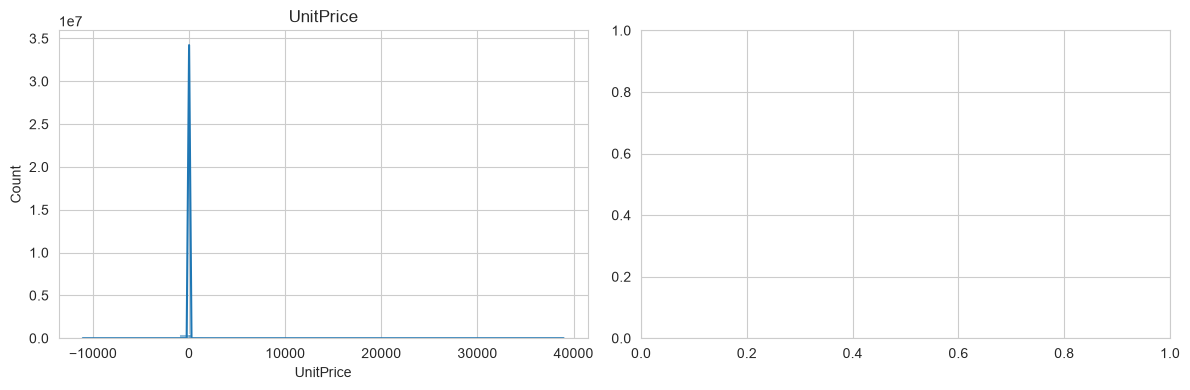

In [49]:
for col in ['UnitPrice', ]:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['UnitPrice'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('UnitPrice')
plt.tight_layout(); plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [51]:
country_sales = df_clean.groupby('Country')['Sales'].sum().reset_index()
total_sales = country_sales['Sales'].sum()
country_sales['Percentage (%)'] = (country_sales['Sales'] / total_sales) * 100
top_country = country_sales.sort_values(by='Sales', ascending=False).iloc[0]
print(f"Quốc gia đóng góp doanh thu cao nhất: {top_country['Country']}")
print(f"Doanh thu: {top_country['Sales']:,.2f}")
print(f"Tỷ lệ đóng góp: {top_country['Percentage (%)']:.2f}%")


Quốc gia đóng góp doanh thu cao nhất: United Kingdom
Doanh thu: 9,025,222.08
Tỷ lệ đóng góp: 84.61%


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [53]:
product_sales = (
    df_clean.groupby(['StockCode', 'Description'])['Sales']
    .sum()
    .reset_index()
)

top_product = product_sales.sort_values(by='Sales', ascending=False).iloc[0]
print(f"Sản phẩm bán chạy nhất theo doanh thu:")
print(f"- Tên sản phẩm (Description): {top_product['Description']}")
print(f"- Tổng doanh thu (Sales): {top_product['Sales']:,.2f}")

Sản phẩm bán chạy nhất theo doanh thu:
- Tên sản phẩm (Description): DOTCOM POSTAGE
- Tổng doanh thu (Sales): 206,248.77


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

--- DOANH SỐ THEO THÁNG ---
YearMonth       Sales
  2010-12  823746.140
  2011-01  691364.560
  2011-02  523631.890
  2011-03  717639.360
  2011-04  537808.621
  2011-05  770536.020
  2011-06  761739.900
  2011-07  719221.191
  2011-08  759138.380
  2011-09 1058590.172
  2011-10 1154979.300
  2011-11 1509496.330
  2011-12  638792.680


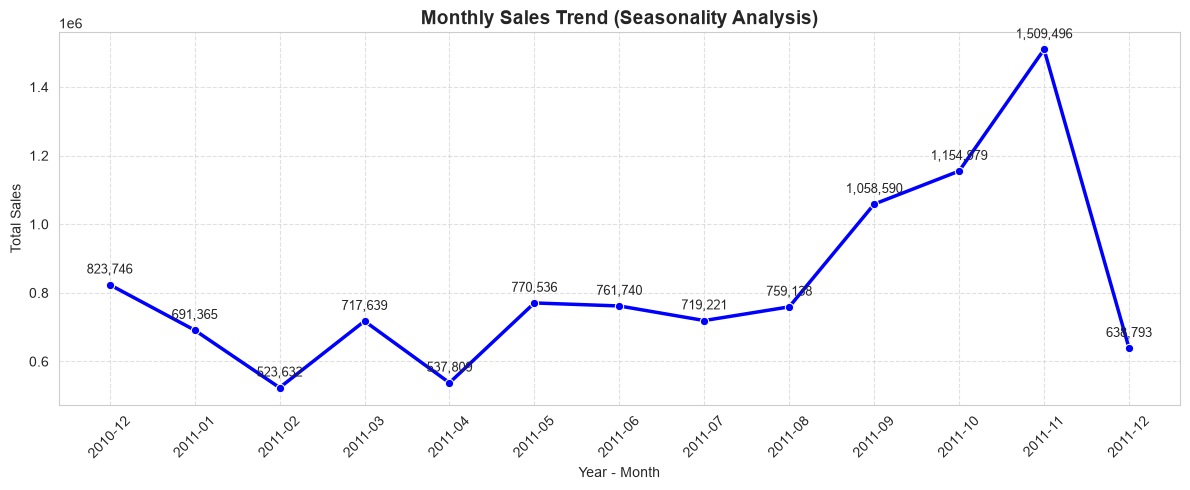

Nhận xét: Biểu đồ cho thấy xu hướng doanh số theo tháng có sự biến động, với các đỉnh cao và thấp rõ rệt, cho thấy có yếu tố mùa vụ ảnh hưởng đến doanh số bán hàng.


In [57]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# 2. Tính tổng doanh số theo từng tháng
monthly_sales = df_clean.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# 3. In bảng kết quả doanh số theo tháng
print("--- DOANH SỐ THEO THÁNG ---")
print(monthly_sales.to_string(index=False))

# 4. Vẽ biểu đồ đường thể hiện xu hướng mùa vụ
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', marker='o', color='b', linewidth=2.5)

plt.title('Monthly Sales Trend (Seasonality Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Year - Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị giá trị lên từng điểm dữ liệu
for i, row in monthly_sales.iterrows():
    plt.annotate(f"{row['Sales']:,.0f}", 
                 (row['YearMonth'], row['Sales']),
                 textcoords="offset points", 
                 xytext=(0, 8), 
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Nhận xét: Biểu đồ cho thấy xu hướng doanh số theo tháng có sự biến động, với các đỉnh cao và thấp rõ rệt, cho thấy có yếu tố mùa vụ ảnh hưởng đến doanh số bán hàng.")

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

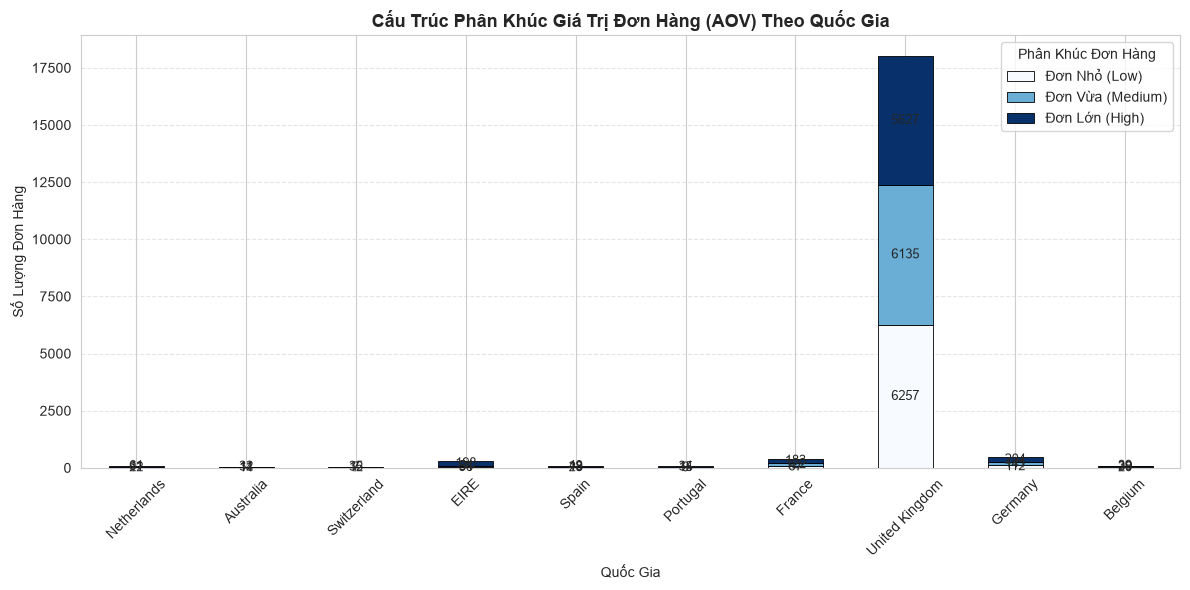

Nhận xét: Biểu đồ cột chồng cho thấy sự phân bố số lượng đơn hàng theo các phân khúc AOVở các quốc gia. Một số quốc gia có tỷ lệ đơn hàng lớn cao hơn, trong khi các quốc gia khác chủ yếu có đơn hàng nhỏ. Điều này phản ánh sự khác biệt về hành vi mua sắm và khả năng chi tiêu của khách hàng ở từng quốc gia.


In [62]:

# 1. Tính Tổng giá trị của từng đơn hàng (InvoiceNo)
order_sales = df_clean.groupby(['InvoiceNo', 'Country'])['Sales'].sum().reset_index()

# 2. Phân loại AOV thành 3 phân khúc (Low, Medium, High)
order_sales['AOV_Segment'] = pd.qcut(
    order_sales['Sales'], 
    q=3, 
    labels=['Đơn Nhỏ (Low)', 'Đơn Vừa (Medium)', 'Đơn Lớn (High)']
)

# 3. Chọn Top 10 quốc gia có nhiều đơn hàng nhất để biểu đồ không bị rối
top_10_countries = order_sales['Country'].value_counts().head(10).index
df_top10 = order_sales[order_sales['Country'].isin(top_10_countries)]

# 4. Tạo bảng Crosstab đếm số lượng đơn hàng theo từng phân khúc
stacked_aov = pd.crosstab(df_top10['Country'], df_top10['AOV_Segment'])

# Tính AOV trung bình thực tế để sắp xếp thứ tự hiển thị
country_aov_mean = df_top10.groupby('Country')['Sales'].mean().sort_values(ascending=False)
stacked_aov = stacked_aov.loc[country_aov_mean.index]

# 5. Vẽ biểu đồ Cột Chồng (Stacked Bar Chart)
ax = stacked_aov.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    colormap='Blues', 
    edgecolor='black', 
    linewidth=0.6
)

plt.title('Cấu Trúc Phân Khúc Giá Trị Đơn Hàng (AOV) Theo Quốc Gia', fontsize=13, fontweight='bold')
plt.xlabel('Quốc Gia')
plt.ylabel('Số Lượng Đơn Hàng')
plt.xticks(rotation=45)
plt.legend(title='Phân Khúc Đơn Hàng')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị số lượng đơn trên từng đoạn cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Nhận xét: Biểu đồ cột chồng cho thấy sự phân bố số lượng đơn hàng theo các phân khúc AOVở các quốc gia. Một số quốc gia có tỷ lệ đơn hàng lớn cao hơn, trong khi các quốc gia khác chủ yếu có đơn hàng nhỏ. Điều này phản ánh sự khác biệt về hành vi mua sắm và khả năng chi tiêu của khách hàng ở từng quốc gia.")

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [68]:
df['Is_Canceled'] = df['Quantity'] < 0
result = df.groupby('Country').agg(
    Total=('InvoiceNo', 'count'),
    Canceled=('Is_Canceled', 'sum')
).reset_index()
result['Rate (%)'] = (result['Canceled'] / result['Total']) * 100
result = result[result['Total'] >= 100].sort_values(by='Rate (%)', ascending=False)

print(result.head(10).round(2).to_string(index=False))
print("Nhận xét: Bảng trên cho thấy tỷ lệ hủy đơn hàng theo từng quốc gia. Một số quốc gia có tỷ lệ hủy đơn hàng cao hơn, điều này có thể phản ánh sự không hài lòng của khách hàng hoặc các vấn đề liên quan đến dịch vụ và sản phẩm tại những quốc gia đó.")

  Country  Total  Canceled  Rate (%)
      USA    291       112     38.49
    Malta    127        15     11.81
    Japan    358        37     10.34
Australia   1259        74      5.88
    Italy    803        45      5.60
  Germany   9495       453      4.77
     EIRE   8196       302      3.68
   Poland    341        11      3.23
Singapore    229         7      3.06
   Sweden    462        11      2.38
Nhận xét: Bảng trên cho thấy tỷ lệ hủy đơn hàng theo từng quốc gia. Một số quốc gia có tỷ lệ hủy đơn hàng cao hơn, điều này có thể phản ánh sự không hài lòng của khách hàng hoặc các vấn đề liên quan đến dịch vụ và sản phẩm tại những quốc gia đó.


Động lực tăng trưởng : Doanh số phụ thuộc mạnh vào tính mùa vụ với sự bùng nổ vượt trội ở Quý 4 do cao điểm lễ hội mua sắm, trong khi Quý 1 ghi nhận mức tiêu thụ thấp nhất năm.Cấu trúc thị trường: Vương quốc Anh đóng vai trò là thị trường trụ cột chiếm phần lớn tổng số lượng giao dịch và doanh thu, nhưng có mô hình mua sắm nhỏ lẻ thường xuyên của khách hàng cá nhân.Phân hóa B2B vs. B2C: Các thị trường xuất khẩu quốc tế ghi nhận giá trị đơn hàng trung bình (AOV) cao vượt trội do tập trung các đơn hàng bán buôn số lượng lớn (B2B).Rủi ro vận hành: Tỷ lệ trả hàng/hủy đơn có sự chênh lệch rõ rệt, đặc biệt cao ở các thị trường quốc tế xa do thời gian giao hàng lâu và chi phí hậu cần phức tạp hơn so với thị trường nội địa.Định hướng chiến lược: Doanh nghiệp cần tập trung tối ưu tồn kho cho Quý 4, đẩy mạnh chính sách chiết khấu bán buôn cho khách quốc tế, đồng thời áp dụng gói combo/mốc Freeship để gia tăng AOV cho thị trường nội địa UK.

*(Viết insight của bạn vào đây...)*